In [1]:
#!pip uninstall torch torchvision torchaudio -y
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [2]:
#!nvcc --version

In [3]:
import time
import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from torch.autograd import grad
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")


Устройство: cuda


Фиксация сида для воспроизводимости эксперимента.

In [4]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Выбор параметры дифференциального уравнения, аналитическое решение уравнения.

In [5]:
beta = 40.0
x_min, x_max = 0.0, 2.0 * np.pi
t_min, t_max = 0.0, 0.2

x_scale = x_max - x_min
t_scale = t_max - t_min

def analytical_solution(x, t):
    return torch.sin(x - beta * t)

Класс модели: четыре линейных слоя и три нелинейных, использующих гиперболический тангенс.

In [6]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 1)
        )
        self.init_weights()

    def init_weights(self):
        def init_weights_layer(m):
            if type(m) == nn.Linear:
                torch.nn.init.xavier_uniform_(m.weight)
                m.bias.data.fill_(0.0)

        self.model.apply(init_weights_layer)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.model(inp)

In [7]:
class BIGPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 1)
        )
        self.init_weights()

    def init_weights(self):
        def init_weights_layer(m):
            if type(m) == nn.Linear:
                torch.nn.init.xavier_uniform_(m.weight)
                m.bias.data.fill_(0.0)

        self.model.apply(init_weights_layer)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.model(inp)

In [8]:
class PeriodicPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = None

        self.model = nn.Sequential(
            nn.Linear(6, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
        self.init_weights()

    def init_weights(self):
        def init_weights_layer(m):
            if type(m) == nn.Linear:
                torch.nn.init.xavier_uniform_(m.weight)
                m.bias.data.fill_(0.0)
        self.model.apply(init_weights_layer)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        sin_x = torch.sin(2 * torch.pi * x)
        cos_x = torch.cos(2 * torch.pi * x)
        sin_t = torch.sin(2 * torch.pi * t)
        cos_t = torch.cos(2 * torch.pi * t)
        features = torch.cat([inp, sin_x, cos_x, sin_t, cos_t], dim=1)
        return self.model(features)

Функции для вычисления невязки дифференциального уравнения и общих потерь. Веса для трех частей, из которых состоят потери, были подобраны в ходе экспериментов.

In [9]:
def pde_residual(model, x_norm, t_norm, beta, x_scale, t_scale):
    x_norm.requires_grad_(True)
    t_norm.requires_grad_(True)

    u = model(x_norm, t_norm)

    u_t_norm = grad(u, t_norm, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x_norm = grad(u, x_norm, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    u_t = u_t_norm / t_scale
    u_x = u_x_norm / x_scale

    return u_t + beta * u_x

def compute_loss(model, points, beta, x_scale, t_scale, weights=(1.0, 50.0, 50.0), l2_lambda=0.0):
    w_pde, w_ic, w_bc = weights
    x_res, t_res = points['pde']

    # PDE residual loss - невязка дифференциального уравнения в частных производных
    loss_pde = torch.mean(pde_residual(model, x_res, t_res, beta, x_scale, t_scale)**2)

    # IC loss - потери, связанные с начальным условием
    x_ic, t_ic, u_ic = points['ic']
    u_ic_pred = model(x_ic, t_ic)
    loss_ic = torch.mean((u_ic_pred - u_ic)**2)

    # BC loss - потери, связанные с граничным условием
    x_l, t_l, x_r, t_r = points['bc']
    u_l = model(x_l, t_l)
    u_r = model(x_r, t_r)
    loss_bc = torch.mean((u_l - u_r)**2)

    total = w_pde * loss_pde + w_ic * loss_ic + w_bc * loss_bc
    total /= (w_pde + w_ic + w_bc)
    if l2_lambda > 0:
        l2_reg = sum(p.norm(2).pow(2) for p in model.parameters())
        total = total + l2_lambda * l2_reg
    return total, loss_pde, loss_ic, loss_bc

Функция, генерирующая набор точек: удовлетворяющих начальному условию, удовлетворяюзих граничному условию, и прочих.

In [10]:
def train(model, points, beta, dtype, device, x_scale, t_scale, epochs_adam=1000, epochs_lbfgs=0,
          lr=1e-3, clipping_on=False, epoch_log_adam=500, epoch_log_lbfgs=100, compare_loss=False,
          l2_lambda=0.0):
    model = model.to(dtype).to(device)
    points_dtype = {}
    points_dtype['pde'] = (points['pde'][0].to(dtype).to(device), points['pde'][1].to(dtype).to(device))
    points_dtype['ic'] = (points['ic'][0].to(dtype).to(device), points['ic'][1].to(dtype).to(device), points['ic'][2].to(dtype).to(device))
    points_dtype['bc'] = (points['bc'][0].to(dtype).to(device), points['bc'][1].to(dtype).to(device),
                          points['bc'][2].to(dtype).to(device), points['bc'][3].to(dtype).to(device))

    with torch.no_grad():
        x_val = torch.linspace(0, 1, 100).reshape(-1, 1).to(dtype).to(device)
        t_val = torch.linspace(0, 1, 100).reshape(-1, 1).to(dtype).to(device)
        X_val, T_val = torch.meshgrid(x_val.squeeze(), t_val.squeeze(), indexing='ij')
        X_flat = X_val.reshape(-1, 1)
        T_flat = T_val.reshape(-1, 1)

        u_exact = analytical_solution(X_flat * x_scale, T_flat * t_scale).cpu().numpy()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=500)
    losses = []

    # Начинаем с оптимайзером Adam для быстрого начального приближения
    for epoch in range(epochs_adam):
        optimizer.zero_grad()
        loss, loss_pde, loss_ic, loss_bc = compute_loss(model, points_dtype, beta, x_scale, t_scale, l2_lambda=l2_lambda)
        loss.backward()

        if clipping_on:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
        optimizer.step()
        scheduler.step(loss)
        losses.append(loss.item())

        if (epoch % epoch_log_adam == 0 or epoch == epochs_adam - 1) and not compare_loss:
            with torch.no_grad():
                u_pred = model(X_flat, T_flat).detach().cpu().numpy()
                mae = np.mean(np.abs(u_pred - u_exact))
                rmse = np.sqrt(np.mean((u_pred - u_exact)**2))
            print(f"[Epochs with Adam {epoch}] Loss: {loss.item():.2e} | MAE: {mae:.4e} | RMSE: {rmse:.4e}")
        if (epoch % epoch_log_adam == 0 or epoch == epochs_adam - 1) and compare_loss:
            with torch.no_grad():
                u_pred = model(X_flat, T_flat).detach().cpu().numpy()
                mae = np.mean(np.abs(u_pred - u_exact))
                rmse = np.sqrt(np.mean((u_pred - u_exact)**2))
            print(f"[Epochs with Adam {epoch}] Loss: {loss.item():.2e} | MAE: {mae:.4e} | RMSE: {rmse:.4e}")
            print(f"Loss IC: {loss_ic.item():.2e} | Loss BC: {loss_bc.item():.2e} | Loss PDE: {loss_pde.item():.2e}")

    # Переходим к L-BFGS для уменьшения потерь после начального приближения
    best_mae = float('inf')
    patience = 100
    wait = 0
    min_delta = 1e-6
    
    if epochs_lbfgs > 0:
        optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=20, tolerance_change=1e-9, tolerance_grad=1e-5, history_size=100)
        for epoch in range(epochs_lbfgs):
            loss_components = {'pde': None, 'ic': None, 'bc': None}
            
            def closure():
                optimizer_lbfgs.zero_grad()
                loss, loss_pde, loss_ic, loss_bc = compute_loss(model, points_dtype, beta, x_scale, t_scale, l2_lambda=l2_lambda)
                
                loss_components['pde'] = loss_pde.detach().item()
                loss_components['ic'] = loss_ic.detach().item()
                loss_components['bc'] = loss_bc.detach().item()
                
                loss.backward()
                return loss

            loss = optimizer_lbfgs.step(closure)
            losses.append(loss.item())

            with torch.no_grad():
                u_pred = model(X_flat, T_flat).detach().cpu().numpy()
                mae = np.mean(np.abs(u_pred - u_exact))
            if mae < best_mae - min_delta:
                best_mae = mae
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

            if (epoch % epoch_log_lbfgs == 0 or epoch == epochs_lbfgs - 1) and not compare_loss:
                with torch.no_grad():
                    u_pred = model(X_flat, T_flat).detach().cpu().numpy()
                    mae = np.mean(np.abs(u_pred - u_exact))
                    rmse = np.sqrt(np.mean((u_pred - u_exact)**2))
                print(f"[Epochs with L-BFGS {epoch}] Loss: {loss.item():.2e} | MAE: {mae:.4e} | RMSE: {rmse:.4e}")
            if (epoch % epoch_log_lbfgs == 0 or epoch == epochs_lbfgs - 1) and compare_loss:
                with torch.no_grad():
                    u_pred = model(X_flat, T_flat).detach().cpu().numpy()
                    mae = np.mean(np.abs(u_pred - u_exact))
                    rmse = np.sqrt(np.mean((u_pred - u_exact)**2))
                print(f"[Epochs with L-BFGS {epoch}] Loss: {loss.item():.2e} | MAE: {mae:.4e} | RMSE: {rmse:.4e}")
                print(f"Loss IC: {loss_components['ic']:.2e} | Loss BC: {loss_components['bc']:.2e} | Loss PDE: {loss_components['pde']:.2e}")

    return losses

In [11]:
def generate_points(n_res=20000, n_ic=500, n_bc=500):
    # Общие точки
    x_res = torch.rand(n_res, 1)
    t_res = torch.rand(n_res, 1)

    # Начальные точки
    x_ic = torch.rand(n_ic, 1)
    t_ic = torch.zeros(n_ic, 1)
    u_ic = analytical_solution(x_ic * x_scale, t_ic)

    # Граничные точки
    t_left = torch.rand(n_bc // 2, 1)
    t_right = torch.rand(n_bc // 2, 1)
    x_left = torch.zeros(n_bc // 2, 1)
    x_right = torch.ones(n_bc // 2, 1)

    return {'pde':(x_res, t_res), 'ic':(x_ic, t_ic, u_ic),
            'bc':(x_left, t_left, x_right, t_right)}

Функция для обучения модели с настраиваеми параметрами.

Генерация точек, подготовка к началу обучения.

In [12]:
points = generate_points(n_res=50000, n_ic=10000, n_bc=10000)

Обучение с использованием FP16.

Как мы видим, произишло переполнение при вычислениях где-то внутри модели. Попробуем уменьшить коэффициент $\beta$, чтобы упросить задачу, и запустим обучение с FP16 еще раз.

Как видим, FP16 для нашей архитектуры является неэффективным даже при низком leraning rate и маленьком $\beta$. Поэтому далее будем сравнивать между собой классический FP32 и FP64.

Запуск обучения для FP32:

In [13]:
model_fp64 = PeriodicPINN()
start = time.time()
losses_fp64 = train(model_fp64, points, beta, torch.float64, device, x_scale, t_scale,
                    epochs_adam=2000,
                    epochs_lbfgs=4000,
                    lr=1e-3,
                    clipping_on=False,
                    epoch_log_adam=500,
                    epoch_log_lbfgs=100,
                    compare_loss=True
                    )
end = time.time()
print(f"Время обучения: {end - start:.2f} секунд")

[Epochs with Adam 0] Loss: 8.96e-01 | MAE: 6.5962e-01 | RMSE: 7.4008e-01
Loss IC: 2.48e-01 | Loss BC: 2.34e-02 | Loss PDE: 7.70e+01
[Epochs with Adam 500] Loss: 8.80e-02 | MAE: 4.9638e-01 | RMSE: 5.7548e-01
Loss IC: 6.36e-02 | Loss BC: 6.18e-02 | Loss PDE: 2.62e+00
[Epochs with Adam 1000] Loss: 8.29e-02 | MAE: 4.9574e-01 | RMSE: 5.7797e-01
Loss IC: 5.64e-02 | Loss BC: 6.88e-02 | Loss PDE: 2.11e+00
[Epochs with Adam 1500] Loss: 8.27e-02 | MAE: 4.9685e-01 | RMSE: 5.7993e-01
Loss IC: 5.60e-02 | Loss BC: 6.90e-02 | Loss PDE: 2.10e+00
[Epochs with Adam 1999] Loss: 8.26e-02 | MAE: 4.9698e-01 | RMSE: 5.8026e-01
Loss IC: 5.59e-02 | Loss BC: 6.90e-02 | Loss PDE: 2.10e+00
[Epochs with L-BFGS 0] Loss: 8.26e-02 | MAE: 4.9735e-01 | RMSE: 5.8102e-01
Loss IC: 5.58e-02 | Loss BC: 6.91e-02 | Loss PDE: 2.09e+00
[Epochs with L-BFGS 100] Loss: 8.21e-02 | MAE: 4.9703e-01 | RMSE: 5.8155e-01
Loss IC: 5.52e-02 | Loss BC: 6.89e-02 | Loss PDE: 2.09e+00
[Epochs with L-BFGS 200] Loss: 8.20e-02 | MAE: 4.9694e-01 |

In [14]:
#model_fp64_base = PINN()
#start = time.time()
#losses_fp64 = train(model_fp64_base, points, beta, torch.float64, device, x_scale, t_scale,
#                    epochs_adam=2000,
#                    epochs_lbfgs=4000,
#                    lr=1e-3,
#                    clipping_on=False,
#                    epoch_log_adam=500,
#                    epoch_log_lbfgs=100,
#                    compare_loss=True)
#end = time.time()
#print(f"Время обучения: {end - start:.2f} секунд")

In [15]:
#model_fp64_big = BIGPINN()
#start = time.time()
#losses_fp64 = train(model_fp64_big, points, beta, torch.float64, device, x_scale, t_scale,
#                    epochs_adam=2000,
#                    epochs_lbfgs=4000,
#                    lr=1e-3,
#                    clipping_on=False,
#                    epoch_log_adam=500,
#                    epoch_log_lbfgs=100,
#                    compare_loss=True)
#end = time.time()
#print(f"Время обучения: {end - start:.2f} секунд")

Запуск обучения для FP64:

In [16]:
model_fp32 = PeriodicPINN()
start = time.time()
losses_fp32 = train(model_fp32, points, beta, torch.float32, device, x_scale, t_scale,
                    epochs_adam=2000,
                    epochs_lbfgs=4000,
                    lr=1e-3,
                    clipping_on=False,
                    epoch_log_adam=500,
                    epoch_log_lbfgs=100,
                    compare_loss=True)
end = time.time()
print(f"Время обучения: {end - start:.2f} секунд")

[Epochs with Adam 0] Loss: 5.24e-01 | MAE: 6.5930e-01 | RMSE: 7.4422e-01
Loss IC: 5.83e-01 | Loss BC: 9.67e-04 | Loss PDE: 2.37e+01
[Epochs with Adam 500] Loss: 8.39e-02 | MAE: 4.9403e-01 | RMSE: 5.7367e-01
Loss IC: 5.93e-02 | Loss BC: 6.94e-02 | Loss PDE: 2.04e+00
[Epochs with Adam 1000] Loss: 8.29e-02 | MAE: 4.9578e-01 | RMSE: 5.7738e-01
Loss IC: 5.63e-02 | Loss BC: 6.90e-02 | Loss PDE: 2.11e+00
[Epochs with Adam 1500] Loss: 8.27e-02 | MAE: 4.9690e-01 | RMSE: 5.7956e-01
Loss IC: 5.61e-02 | Loss BC: 6.90e-02 | Loss PDE: 2.10e+00
[Epochs with Adam 1999] Loss: 8.26e-02 | MAE: 4.9671e-01 | RMSE: 5.7990e-01
Loss IC: 5.62e-02 | Loss BC: 6.86e-02 | Loss PDE: 2.10e+00
[Epochs with L-BFGS 0] Loss: 8.27e-02 | MAE: 4.9741e-01 | RMSE: 5.8058e-01
Loss IC: 5.60e-02 | Loss BC: 6.92e-02 | Loss PDE: 2.08e+00
[Epochs with L-BFGS 100] Loss: 8.21e-02 | MAE: 4.9704e-01 | RMSE: 5.8157e-01
Loss IC: 5.53e-02 | Loss BC: 6.89e-02 | Loss PDE: 2.09e+00
Early stopping at epoch 125
Время обучения: 133.61 секунд


In [17]:
model_fp64_l2 = PeriodicPINN()
start = time.time()
losses_fp64_l2 = train(model_fp64_l2, points, beta, torch.float64, device, x_scale, t_scale,
                    epochs_adam=2000,
                    epochs_lbfgs=4000,
                    lr=1e-3,
                    clipping_on=False,
                    epoch_log_adam=500,
                    epoch_log_lbfgs=100,
                    compare_loss=True,
                    l2_lambda=1e-6)
end = time.time()
print(f"Время обучения: {end - start:.2f} секунд")

[Epochs with Adam 0] Loss: 1.20e+00 | MAE: 6.2745e-01 | RMSE: 7.0335e-01
Loss IC: 3.96e-01 | Loss BC: 2.03e-01 | Loss PDE: 9.11e+01
[Epochs with Adam 500] Loss: 8.43e-02 | MAE: 4.9469e-01 | RMSE: 5.7502e-01
Loss IC: 5.83e-02 | Loss BC: 6.86e-02 | Loss PDE: 2.13e+00
[Epochs with Adam 1000] Loss: 8.35e-02 | MAE: 4.9628e-01 | RMSE: 5.7864e-01
Loss IC: 5.66e-02 | Loss BC: 6.90e-02 | Loss PDE: 2.11e+00
[Epochs with Adam 1500] Loss: 9.62e-02 | MAE: 4.9906e-01 | RMSE: 5.8202e-01
Loss IC: 5.48e-02 | Loss BC: 8.03e-02 | Loss PDE: 2.91e+00
[Epochs with Adam 1999] Loss: 8.33e-02 | MAE: 4.9812e-01 | RMSE: 5.8121e-01
Loss IC: 5.55e-02 | Loss BC: 7.04e-02 | Loss PDE: 2.07e+00
[Epochs with L-BFGS 0] Loss: 8.32e-02 | MAE: 4.9709e-01 | RMSE: 5.8043e-01
Loss IC: 5.57e-02 | Loss BC: 6.93e-02 | Loss PDE: 2.10e+00
[Epochs with L-BFGS 100] Loss: 8.24e-02 | MAE: 4.9700e-01 | RMSE: 5.8164e-01
Loss IC: 5.53e-02 | Loss BC: 6.88e-02 | Loss PDE: 2.09e+00
Early stopping at epoch 131
Время обучения: 220.85 секунд


In [18]:
model_fp16 = PINN()
losses_fp16 = train(model_fp16, points, beta, torch.float16, device, x_scale, t_scale, epochs_adam=50, epochs_lbfgs=0,
                    lr=1e-7, clipping_on=True, epoch_log_adam=10, epoch_log_lbfgs=0, compare_loss=False)

[Epochs with Adam 0] Loss: 3.40e-01 | MAE: nan | RMSE: nan
[Epochs with Adam 10] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 20] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 30] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 40] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 49] Loss: nan | MAE: nan | RMSE: nan


In [19]:
model_fp16_easy = PINN()
losses_fp16_easy = train(model_fp16_easy, points, 5, torch.float16, device, x_scale, t_scale, epochs_adam=500, epochs_lbfgs=0,
                         lr=1e-7, clipping_on=True, epoch_log_adam=50, epoch_log_lbfgs=0, compare_loss=False)

[Epochs with Adam 0] Loss: 2.62e-01 | MAE: nan | RMSE: nan
[Epochs with Adam 50] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 100] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 150] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 200] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 250] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 300] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 350] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 400] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 450] Loss: nan | MAE: nan | RMSE: nan
[Epochs with Adam 499] Loss: nan | MAE: nan | RMSE: nan


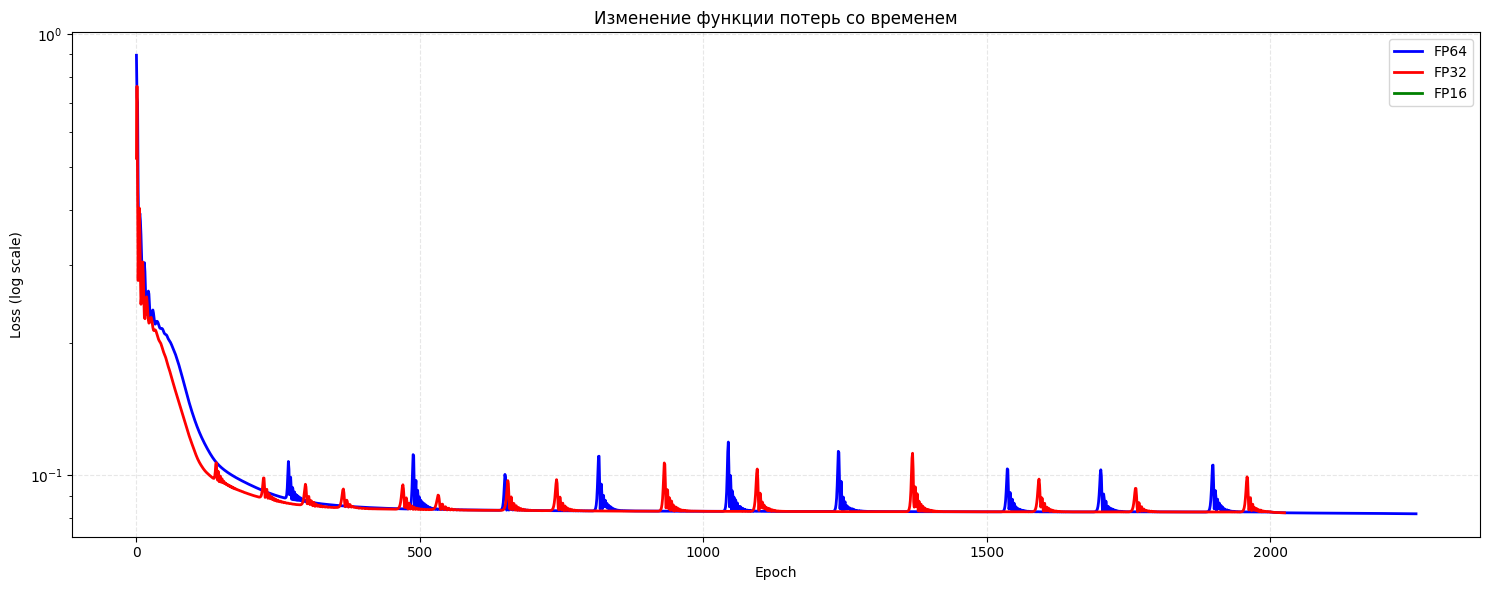

In [20]:
plt.figure(figsize=(15, 6))

plt.semilogy(losses_fp64, label='FP64', linewidth=2, color='blue')
plt.semilogy(losses_fp32[:-100], label='FP32', linewidth=2, color='red')
plt.semilogy(losses_fp16, label='FP16', linewidth=2, color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Изменение функции потерь со временем')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

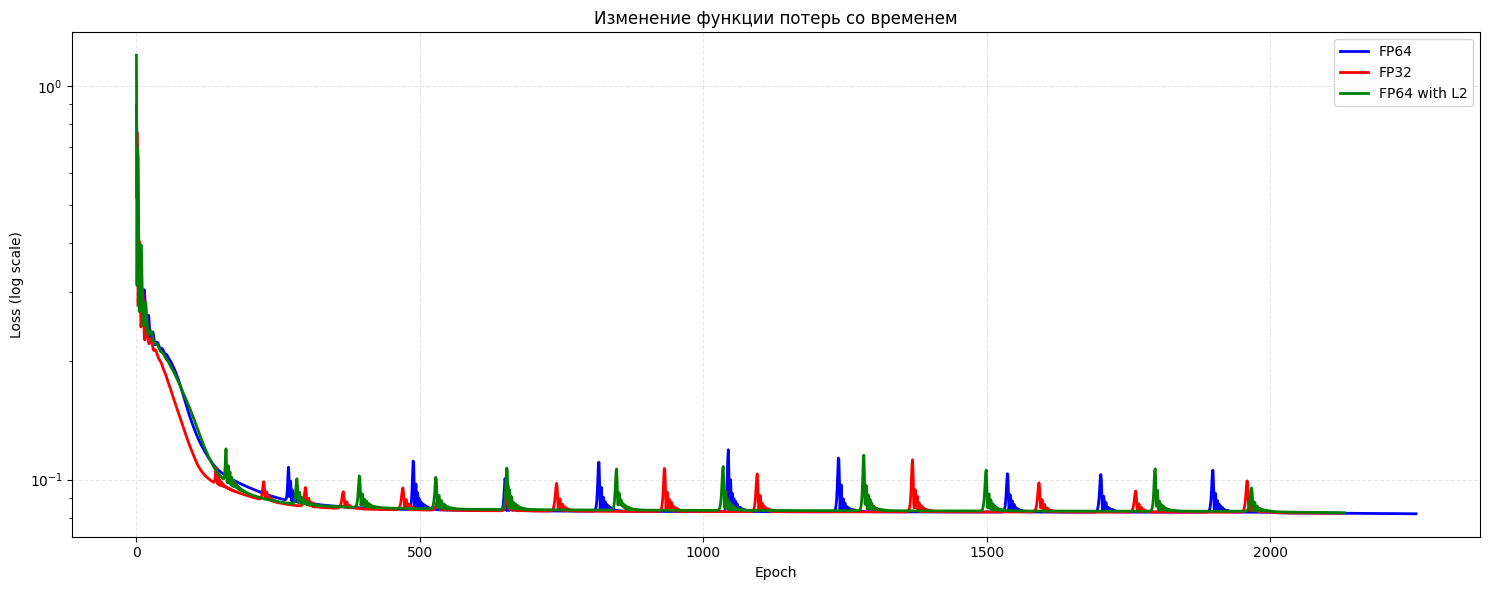

In [21]:
plt.figure(figsize=(15, 6))

plt.semilogy(losses_fp64, label='FP64', linewidth=2, color='blue')
plt.semilogy(losses_fp32, label='FP32', linewidth=2, color='red')
plt.semilogy(losses_fp64_l2, label='FP64 with L2', linewidth=2, color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Изменение функции потерь со временем')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

def plot_results(model, dtype, name, beta, x_min, x_max, t_min, t_max, n_x=150, n_t=80):
    # Создание сетки
    x_vals = torch.linspace(x_min, x_max, n_x).reshape(-1, 1)
    t_vals = torch.linspace(t_min, t_max, n_t).reshape(-1, 1)
    X, T = torch.meshgrid(x_vals.squeeze(), t_vals.squeeze(), indexing='ij')
    X_flat = X.reshape(-1, 1)
    T_flat = T.reshape(-1, 1)

    X_norm = X_flat / x_scale
    T_norm = T_flat / t_scale

    # Теоретическое решение
    u_exact = analytical_solution(X_flat, T_flat).numpy().reshape(n_x, n_t)

    # Предсказания модели
    model = model.to(dtype).cpu()
    with torch.no_grad():
        u_pred = model(X_norm.to(dtype), T_norm.to(dtype)).cpu().numpy().reshape(n_x, n_t)

    error = np.abs(u_pred - u_exact)

    # Графики
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    с1 = axes[0].imshow(u_exact, extent=[t_min, t_max, x_min, x_max],
                         origin='lower', aspect='auto', cmap='viridis')

    axes[0].set_xlabel('t')
    axes[0].set_ylabel('x')
    axes[0].set_title('Точное решение')
    plt.colorbar(с1, ax=axes[0], label='u(x,t)')

    с2 = axes[1].imshow(u_pred, extent=[t_min, t_max, x_min, x_max],
                         origin='lower', aspect='auto', cmap='viridis')

    axes[1].set_xlabel('t')
    axes[1].set_ylabel('x')
    axes[1].set_title(f'Предсказания {name}')
    plt.colorbar(с2, ax=axes[1], label='u(x,t)')

    с3 = axes[2].imshow(error, extent=[t_min, t_max, x_min, x_max],
                         origin='lower', aspect='auto', cmap='inferno')
    axes[2].set_xlabel('t')
    axes[2].set_ylabel('x')
    axes[2].set_title(f'Абсолютная ошибка')
    plt.colorbar(с3, ax=axes[2], label='|u_pred - u_exact|')

    plt.suptitle(f'Решения для {name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Возврат ошибок для таблицы
    mae = np.mean(error)
    rmse = np.sqrt(np.mean(error**2))
    return mae, rmse

Обучение с FP64


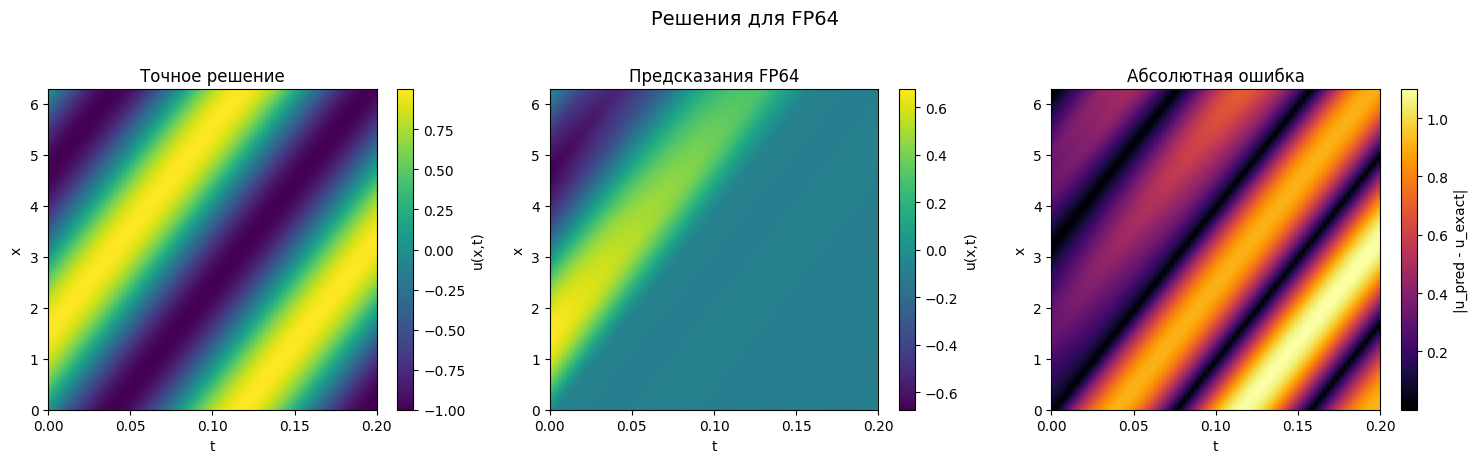

Обучение с FP32


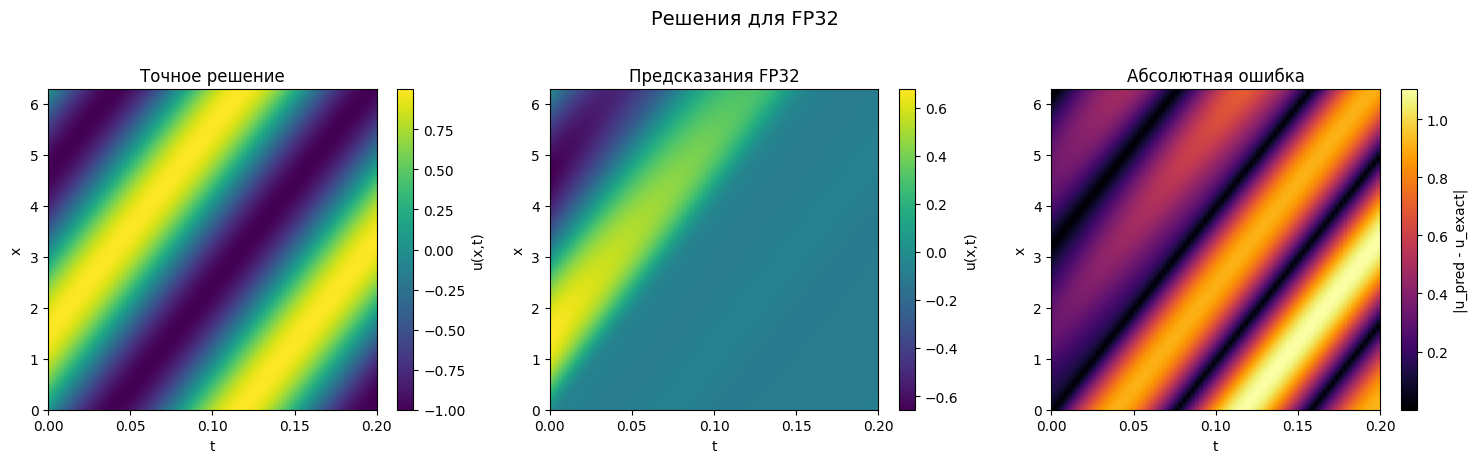

Обучение с FP64 и L2 регуляризацией


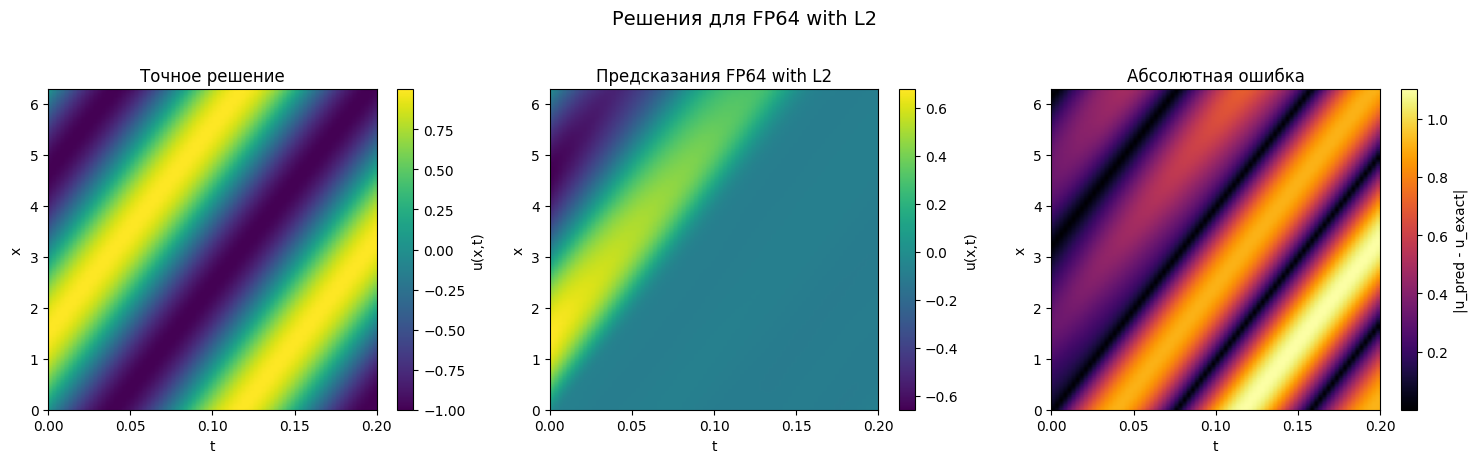

ValueError: Length of values (2) does not match length of index (3)

In [23]:
metrics = {}

# Построение графиков

print("Обучение с FP64")
mae, rmse = plot_results(model_fp64, torch.float64, 'FP64', beta, x_min, x_max, t_min, t_max)
metrics['FP64'] = (mae, rmse)

print("Обучение с FP32")
mae, rmse = plot_results(model_fp32, torch.float32, 'FP32', beta, x_min, x_max, t_min, t_max)
metrics['FP32'] = (mae, rmse)

print("Обучение с FP64 и L2 регуляризацией")
mae, rmse = plot_results(model_fp64_l2, torch.float64, 'FP64 with L2', beta, x_min, x_max, t_min, t_max)
metrics['FP64_L2'] = (mae, rmse)

#Таблица MAE и RMSE

metrics_df = pd.DataFrame(metrics, index=['MAE', 'RMSE', 'FP64_L2']).T
print("Сравнение MAE и RMSE для разных типов данных")
print(metrics_df.round(6))